# *Phan Anh thoải mái chấm phá nhé*

# **Triển khai dự án Data Science - Project 1 - Machine Learning with traditional Python**


# **Business Understanding**
* **Bối cảnh:** Dữ liệu nhà ở được đăng bán trên Nhà Tốt.
* **Nhu cầu:**
  * *Người bán:* cần gợi ý giá hợp lý, không bị “hớ” → Đồng thời
cung cấp giá phù hợp cho người mua.
  * *Nền tảng/kiểm duyệt:* cần cảnh báo tin đăng bài bán nhà có
giá bất thường để xử lý.
* **Xác định vấn đề:**
  * *Mục tiêu/ vấn đề:*
    * Xây dựng mô hình dự đoán & gợi ý giá đăng bán hợp lý.
    * Phát hiện bất thường: bài đăng đưa giá quá thấp/quá cao.
  * *Xây dựng mô hình:*
    * Dự đoán giá.
    * Phát hiện bất thường.

# **Import thư viện**

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import time

import warnings
warnings.filterwarnings('ignore')

In [3]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# import joblib

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# **Đọc dữ liệu**

## *Xác định vị trí lưu trữ dữ liệu trong drive của mình*

In [76]:
# from google.colab import drive
# drive.mount('/content/gdrive', force_remount=True)

In [77]:
# # Gắn mốc tại đường dẫn thư mục lưu file dữ liệu (của ĐÔNG HY)
# %cd '/content/gdrive/MyDrive/Cung cap HV'

In [78]:
# Gắn mốc tại đường dẫn thư mục lưu file dữ liệu (Của các anh em)
# %cd '/content/gdrive/MyDrive/Cung cap HV'

In [79]:
# pwd  # Check đường dẫn

In [80]:
# ls  # Xem danh sách file trong thư mục

## *Đọc dữ liệu*

In [18]:
cd C:/DL07_Do_An/Streamlit_project

C:\DL07_Do_An\Streamlit_project


In [19]:
# Đọc dữ liệu
df=pd.read_csv('C:\DL07_Do_An\data_1\well_formed_data.csv')
print(f"Kích thước dữ liệu: {df.shape}")

Kích thước dữ liệu: (7892, 26)


In [20]:
df.head(3)

,gia_ban,loai_hinh,dien_tich_dat,giay_to_phap_ly,so_phong_ngu,so_phong_ve_sinh,tong_so_tang,tinh_trang_noi_that,dac_diem,chieu_ngang,...,vi_tri_trung_tam,truong_hoc,san_bay,benh_vien,sieu_thi,giao_thong,giai_tri,dia_diem_dac_biet,phuong,gia_m2_tham_khao
0,3.850000e+09,"Nhà ngõ, hẻm",36.0,Đã có sổ,2.0,2.0,2.0,Nội thất đầy đủ,Nhà nở hậu,4.5,...,True,True,True,True,False,False,False,False,Phường Gia Định,140.91
1,9.790000e+09,"Nhà ngõ, hẻm",62.0,Chưa xác định,4.0,3.0,3.0,Không rõ,Thông thường,4.2,...,True,False,True,False,False,False,False,False,Phường Bình Lợi Trung,140.00
2,7.200000e+09,"Nhà ngõ, hẻm",54.0,Đã có sổ,3.0,2.0,2.0,Hoàn thiện cơ bản,Hẻm xe hơi,7.0,...,True,False,True,False,False,False,False,False,Phường Bình Lợi Trung,151.05


In [84]:
df.columns

Index(['gia_ban', 'loai_hinh', 'dien_tich_dat', 'giay_to_phap_ly',
       'so_phong_ngu', 'so_phong_ve_sinh', 'tong_so_tang',
       'tinh_trang_noi_that', 'dac_diem', 'chieu_ngang', 'duong_lon',
       'vi_tri_dat', 'garage', 'san_vuon', 'hai_mat_tien', 'view',
       'vi_tri_trung_tam', 'truong_hoc', 'san_bay', 'benh_vien', 'sieu_thi',
       'giao_thong', 'giai_tri', 'dia_diem_dac_biet', 'phuong',
       'gia_m2_tham_khao'],
      dtype='object')

## **Handle Outliers - Mình chỉ thử nghiệm, bạn hoàn toàn có thể bỏ khối bước này nhá**

In [85]:
'''
PA:
Cần Loại bỏ 5% top outlier và 5% bottom outlier (Mình có test thử mấy ngưỡng khác nhưng ngưỡng này là hợp lý) --> R2 tăng mạnh
'''

'\nPA:\nCần Loại bỏ 5% top outlier và 5% bottom outlier (Mình có test thử mấy ngưỡng khác nhưng ngưỡng này là hợp lý) --> R2 tăng mạnh\n'

In [21]:
def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.05)
    Q3 = df[col].quantile(0.95)
    IQR = Q3 - Q1
    # Chỉ giữ lại dữ liệu nằm trong "vùng an toàn"
    return df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

In [22]:
# Cắt bỏ outliers cho 2 biến dễ gây nhiễu nhất
df = remove_outliers_iqr(df, 'gia_ban')
print(f"Số lượng sau khi 'trảm' Outliers: {len(df)} căn nhà")

Số lượng sau khi 'trảm' Outliers: 7859 căn nhà


# **Trực quan hóa dữ liệu (trước khi transform)**

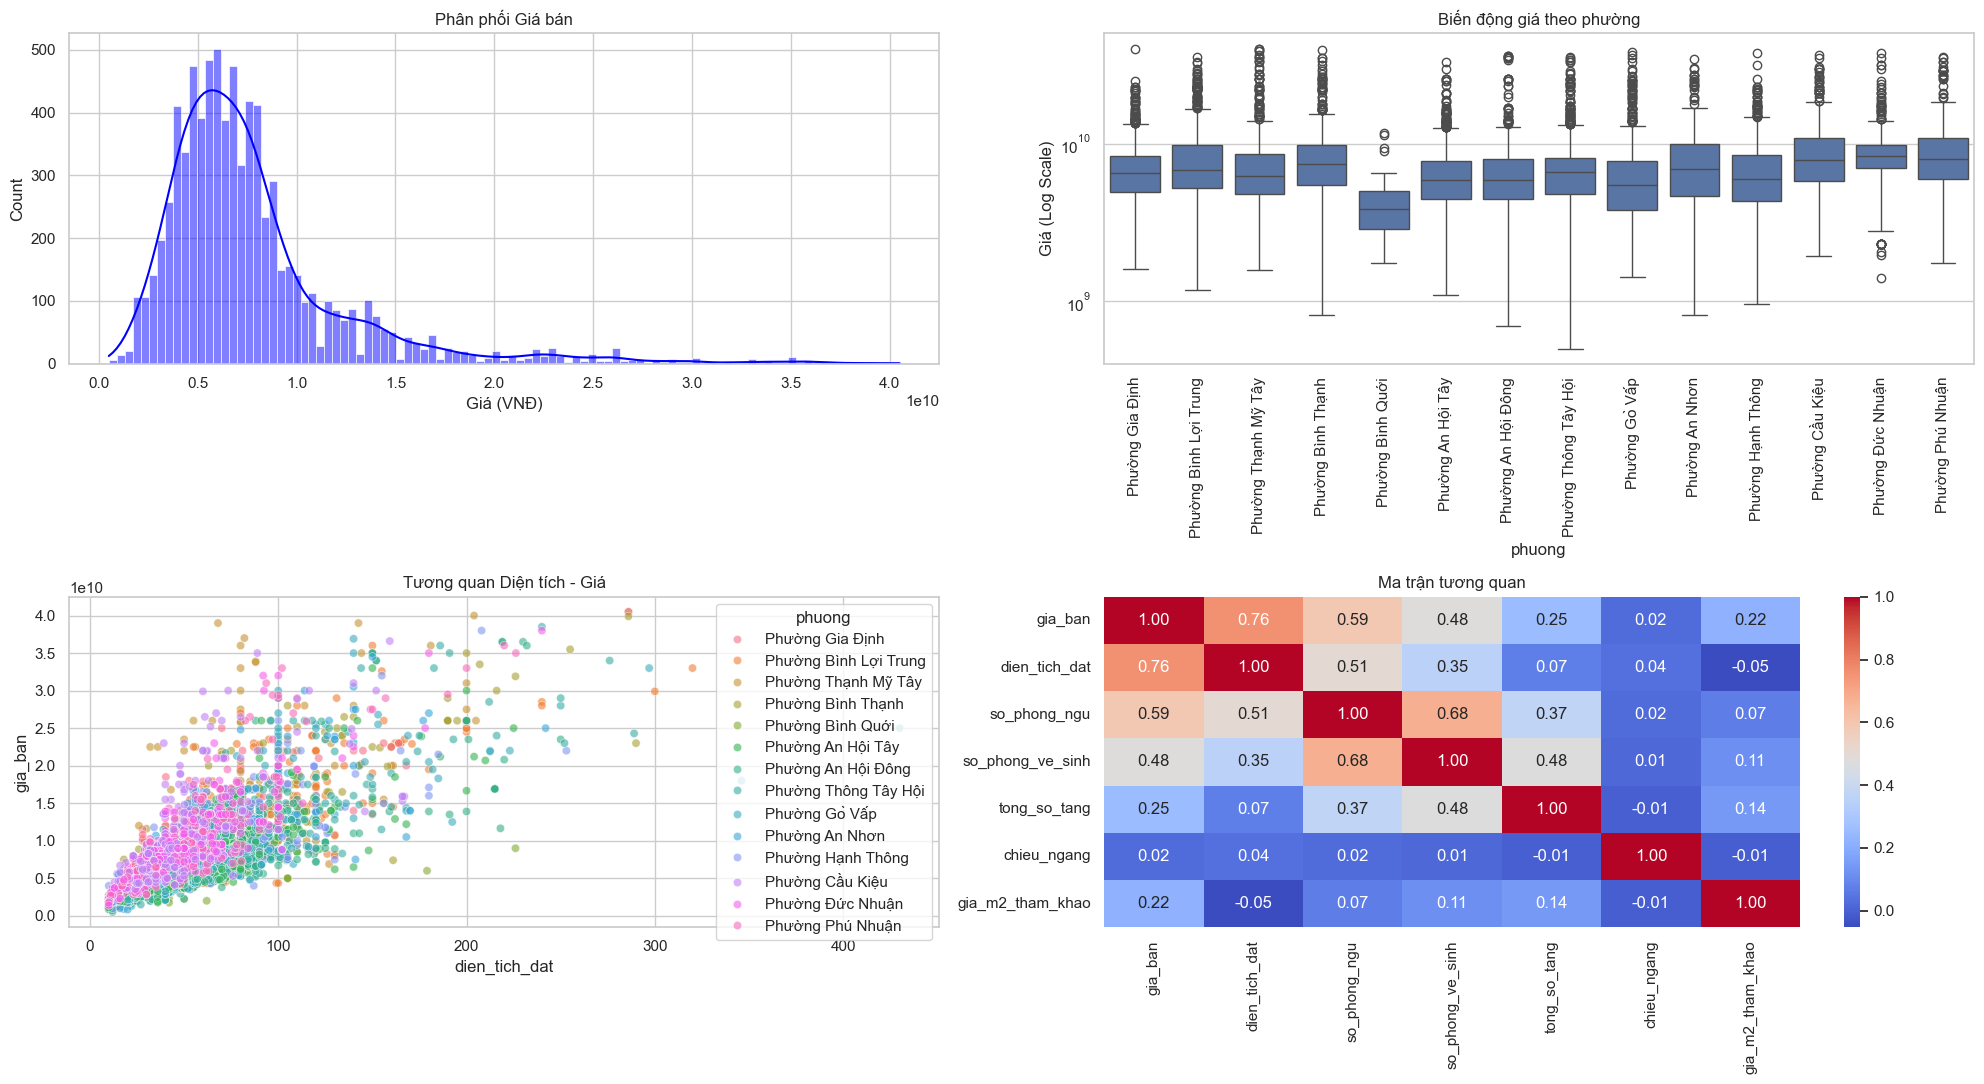

In [88]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (20, 11)

# lưới biểu đồ 2x2
fig, axes = plt.subplots(2, 2)

# phân phối giá
sns.histplot(df['gia_ban'], kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('Phân phối Giá bán')
axes[0, 0].set_xlabel('Giá (VNĐ)')

# giá theo phường
sns.boxplot(x='phuong', y='gia_ban', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Biến động giá theo phường')
axes[0, 1].set_yscale('log') # Dùng thang log để dễ nhìn các hộp
axes[0, 1].set_ylabel('Giá (Log Scale)')
axes[0, 1].tick_params(axis='x', rotation=90)

# tương quan diện tích - giá cả
sns.scatterplot(x='dien_tich_dat', y='gia_ban', hue='phuong', data=df, ax=axes[1, 0], alpha=0.6)
axes[1, 0].set_title('Tương quan Diện tích - Giá')

# heatmap - tương quan các biến
# chỉ lấy các cột số để tính tương quan
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title('Ma trận tương quan')

plt.tight_layout()
plt.show()

### **Nhận xét**

* Phân phối Giá bán (Histogram)
  * **Nhận xét:** Dữ liệu có sự lệch phải lớn. Phần lớn các căn nhà tập trung ở mức giá thấp (cột cao bên trái), trong khi chỉ có một vài căn cao cấp có giá hàng chục tỷ kéo dài cái đuôi về bên phải.
    * **Hệ quả:** Nếu để nguyên như vậy, mô hình sẽ bị xao nhãng bởi các căn giá rẻ và dự báo rất sai cho các căn cao cấp.
  * **Hành động:** Dùng Log Transformation để kéo cho đuôi cân bằng, đưa phân phối về dạng chuẩn.

* Biến động giá theo Quận (Boxplot)
  * **Nhận xét:**  Các dải giá ở các phường đều khác nhau rõ. Điều này chứng tỏ vị trí đóng vai trò không nhỏ.
  * Cột `phuong` là một đặc trưng tốt, có vai trò lớn.

* Tương quan Diện tích - Giá (Scatter Plot)
  * **Nhận xét:** Có một xu hướng tuyến tính: **Diện tích tăng thì giá tăng**. Tuy nhiên, các điểm dữ liệu quá tập trung tại một nơi ở góc dưới bên trái do thang đo của hai trục quá lệch nhau (Diện tích chỉ vài chục, giá tới hàng tỷ $10^{9}$).
  * **Hành động:** Cần StandardScaler các features. Nếu đưa cả hai về cùng một hệ quy chiếu, các điểm dữ liệu trải đều hơn, giúp thuật toán tính toán khoảng cách chính xác hơn.

* Ma trận tương quan (Heatmap)
  * **Nhận xét:** `dien_tich_dat` và `gia_ban` có tương quan `0.75`: Một mối quan hệ tương đối mạnh, cho thấy vai trò của diện tích đối với giá.

# **Data Transformation**

In [23]:
df_transformed = df.copy()

In [90]:
df_transformed.columns

Index(['gia_ban', 'loai_hinh', 'dien_tich_dat', 'giay_to_phap_ly',
       'so_phong_ngu', 'so_phong_ve_sinh', 'tong_so_tang',
       'tinh_trang_noi_that', 'dac_diem', 'chieu_ngang', 'duong_lon',
       'vi_tri_dat', 'garage', 'san_vuon', 'hai_mat_tien', 'view',
       'vi_tri_trung_tam', 'truong_hoc', 'san_bay', 'benh_vien', 'sieu_thi',
       'giao_thong', 'giai_tri', 'dia_diem_dac_biet', 'phuong',
       'gia_m2_tham_khao'],
      dtype='object')

## *Log Transform biến mục tiêu*

In [24]:
df_transformed['log_gia_vnd'] = np.log1p(df_transformed['gia_ban'])

## *Standard Scaling*

In [25]:
from sklearn.preprocessing import StandardScaler

In [26]:
scaler = StandardScaler()

In [27]:
# StandardScaler để thu nhỏ các số lớn về quanh mốc 0
num_cols = ['dien_tich_dat','so_phong_ngu','so_phong_ve_sinh','tong_so_tang', 'gia_m2_tham_khao', 'chieu_ngang']
df_transformed[num_cols] = scaler.fit_transform(df_transformed[num_cols])

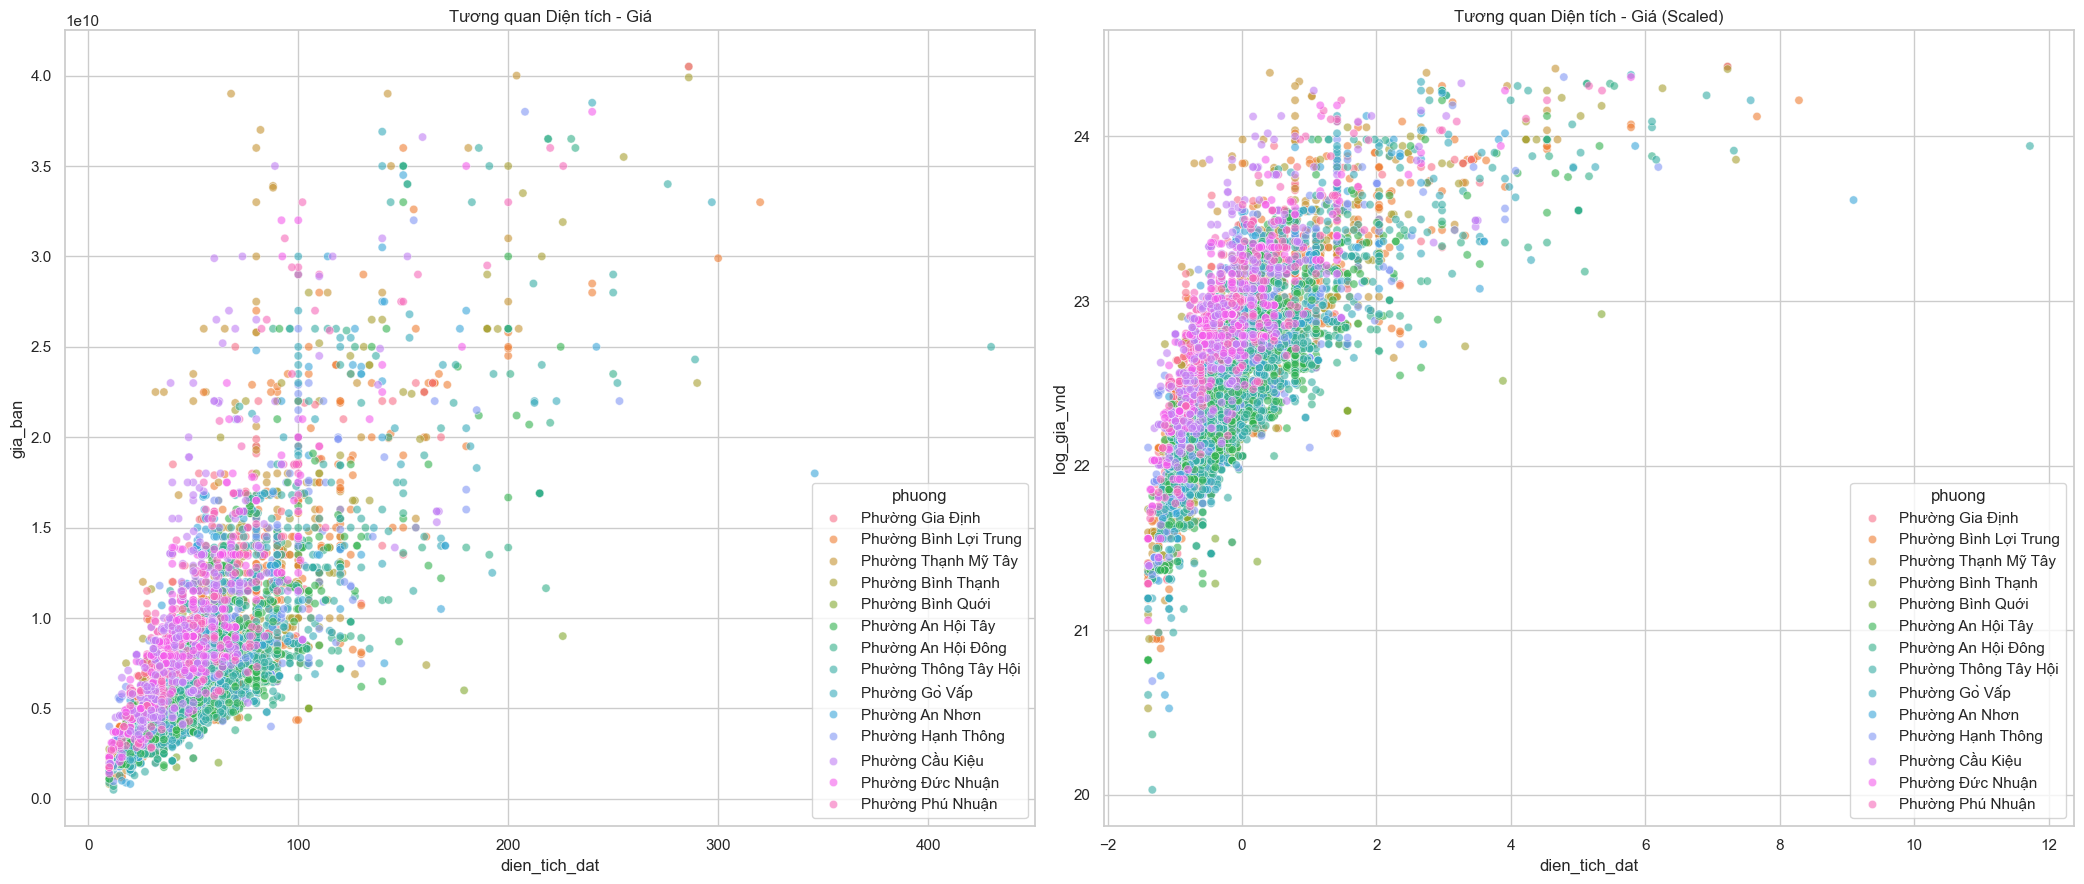

In [95]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(21, 9))

# tương quan diện tích - giá cả ban đầu
sns.scatterplot(x='dien_tich_dat', y='gia_ban', hue='phuong', data=df, ax=axes[0], alpha=0.6)
axes[0].set_title('Tương quan Diện tích - Giá')

# tương quan diện tích - giá cả sau khi scale
sns.scatterplot(x='dien_tich_dat', y='log_gia_vnd', hue='phuong', data=df_transformed, ax=axes[1], alpha=0.6)
axes[1].set_title('Tương quan Diện tích - Giá (Scaled)')

plt.tight_layout()
plt.show()

## *Categorical Encoding*

In [28]:
import re

In [29]:
# Mã hóa biến phân loại
cat_cols = ['phuong', 'loai_hinh', 'giay_to_phap_ly', 'dac_diem', 'tinh_trang_noi_that']
df_transformed = pd.get_dummies(df_transformed, columns=cat_cols, drop_first=True)

In [30]:
# làm sạch tên cột
def clean_col_names(df):
    # Thay thế tất cả các ký tự không phải chữ cái/số bằng dấu "_"
    df.columns = [re.sub(r'[^\w]', '_', col) for col in df.columns]

    # Loại bỏ trường hợp nhiều dấu gạch dưới liên tiếp -> 1 dấu
    df.columns = [re.sub(r'_+', '_', col).strip('_') for col in df.columns]
    return df

In [31]:
# Áp dụng
df_transformed = clean_col_names(df_transformed)
# Kiểm tra
df_transformed.columns

Index(['gia_ban', 'dien_tich_dat', 'so_phong_ngu', 'so_phong_ve_sinh',
       'tong_so_tang', 'chieu_ngang', 'duong_lon', 'vi_tri_dat', 'garage',
       'san_vuon', 'hai_mat_tien', 'view', 'vi_tri_trung_tam', 'truong_hoc',
       'san_bay', 'benh_vien', 'sieu_thi', 'giao_thong', 'giai_tri',
       'dia_diem_dac_biet', 'gia_m2_tham_khao', 'log_gia_vnd',
       'phuong_Phường_An_Hội_Đông', 'phuong_Phường_An_Nhơn',
       'phuong_Phường_Bình_Lợi_Trung', 'phuong_Phường_Bình_Quới',
       'phuong_Phường_Bình_Thạnh', 'phuong_Phường_Cầu_Kiệu',
       'phuong_Phường_Gia_Định', 'phuong_Phường_Go_Vâ_p',
       'phuong_Phường_Ha_nh_Thông', 'phuong_Phường_Phú_Nhuận',
       'phuong_Phường_Thông_Tây_Hội', 'phuong_Phường_Thạnh_Mỹ_Tây',
       'phuong_Phường_Đức_Nhuận', 'loai_hinh_Nhà_mặt_phố_mặt_tiền',
       'loai_hinh_Nhà_ngõ_hẻm', 'loai_hinh_Nhà_phố_liền_kề',
       'giay_to_phap_ly_Giấy_tờ_viết_tay', 'giay_to_phap_ly_Không_có_sổ',
       'giay_to_phap_ly_Sổ_chung_công_chứng_vi_bằng',
       'gia

In [100]:
df_transformed.head(2)

,gia_ban,dien_tich_dat,so_phong_ngu,so_phong_ve_sinh,tong_so_tang,chieu_ngang,duong_lon,vi_tri_dat,garage,san_vuon,...,dac_diem_Nhà_dính_quy_hoạch_lộ_giới,dac_diem_Nhà_nát,dac_diem_Nhà_nở_hậu,dac_diem_Nhà_tóp_hậu,dac_diem_Thông_thường,dac_diem_Đất_chưa_chuyển_thổ,tinh_trang_noi_that_Hoàn_thiện_cơ_bản,tinh_trang_noi_that_Không_rõ,tinh_trang_noi_that_Nội_thất_cao_cấp,tinh_trang_noi_that_Nội_thất_đầy_đủ
0,3.850000e+09,-0.584202,-0.84599,-0.981235,-0.720879,-0.011218,True,False,False,False,...,False,False,True,False,False,False,False,False,False,True
1,9.790000e+09,0.227788,0.26341,-0.197225,0.006665,-0.017804,False,False,False,False,...,False,False,False,False,True,False,False,True,False,False


# **Trực quan hóa dữ liệu (sau khi transform)**

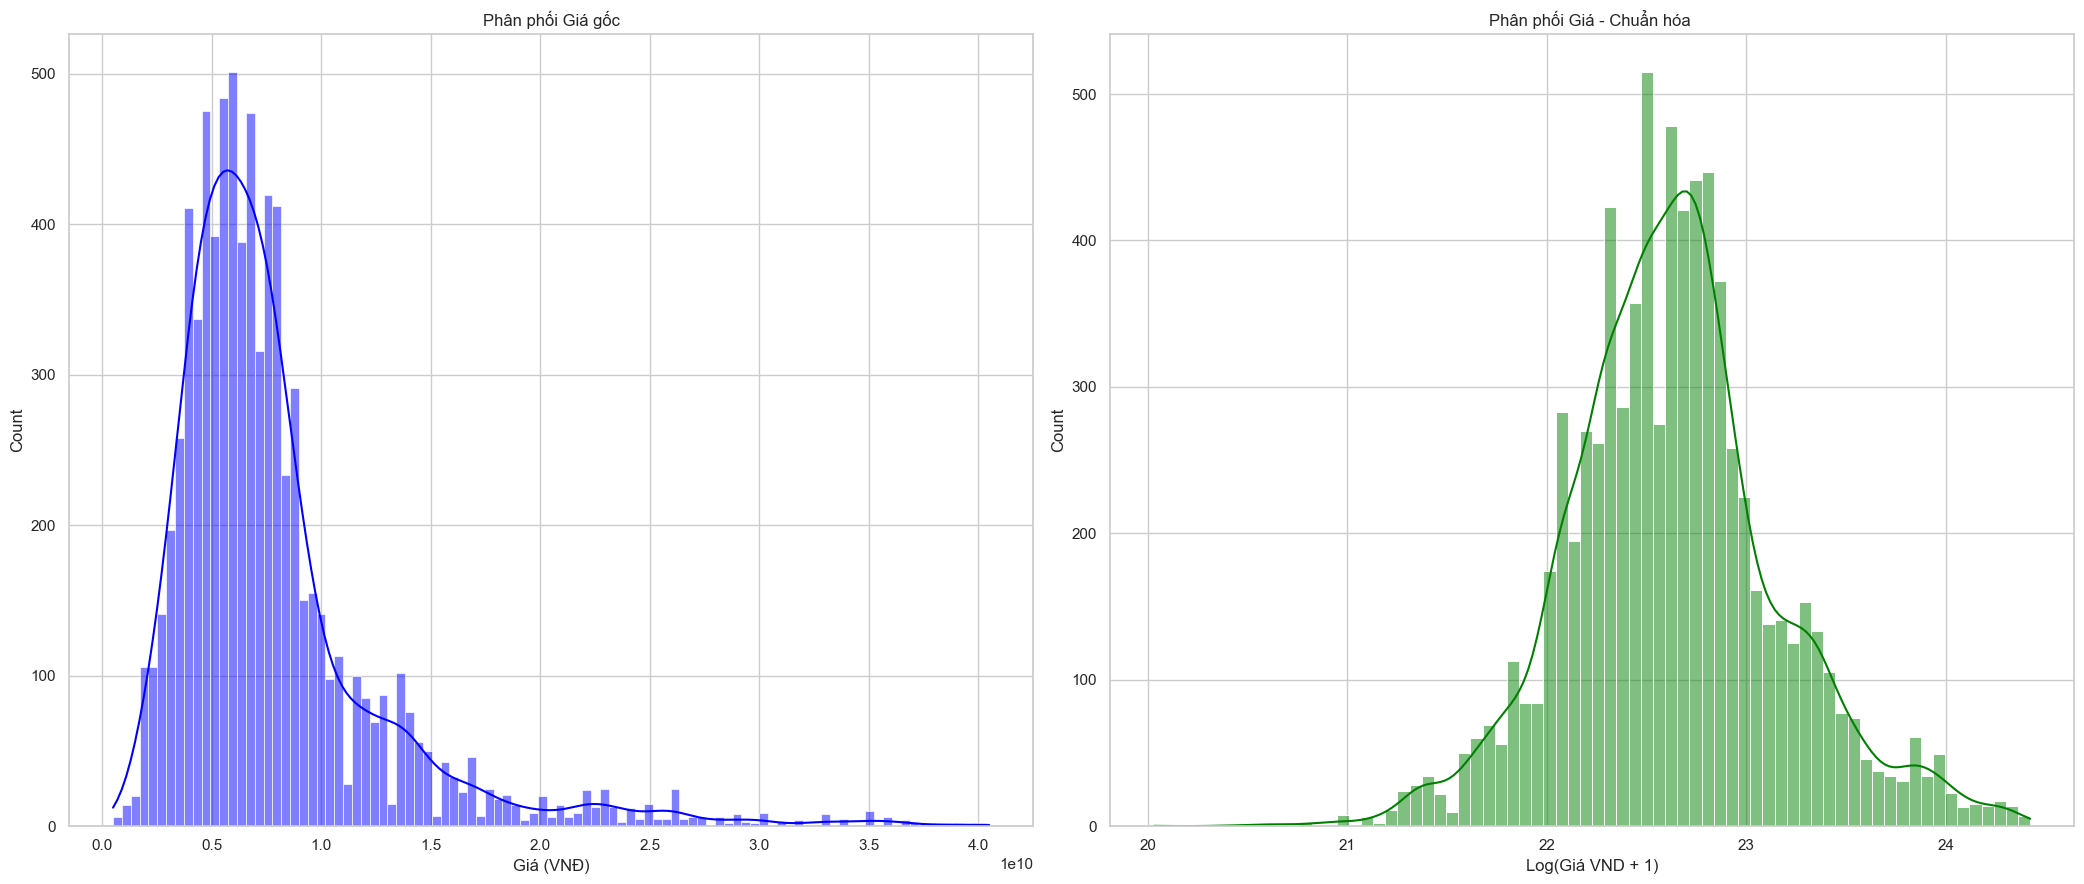

In [101]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(21, 9))

# phân phối ban đầu
sns.histplot(df['gia_ban'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Phân phối Giá gốc')
axes[0].set_xlabel('Giá (VNĐ)')

# phân phối sau khi scale
sns.histplot(df_transformed['log_gia_vnd'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Phân phối Giá - Chuẩn hóa ')
axes[1].set_xlabel('Log(Giá VND + 1)')

plt.tight_layout()
plt.show()

# **Train - Test Splitting**

In [102]:
'''
PA:
models bên dưới mình có dùng gia_m2_tham_khao nha
Mình cũng bổ sung lại tinh_trang_noi_that ở bên data preprocessing, những cái nan thì cũng điền không rõ luôn
--> Không bị mất thông tin --> tăng R2

Target y nên để bình thường không lấy log khi chạy model --> Giúp cho R2 Score tăng mạnh
'''

'\nPA:\nmodels bên dưới mình có dùng gia_m2_tham_khao nha\nMình cũng bổ sung lại tinh_trang_noi_that ở bên data preprocessing, những cái nan thì cũng điền không rõ luôn\n--> Không bị mất thông tin --> tăng R2\n\nTarget y nên để bình thường không lấy log khi chạy model --> Giúp cho R2 Score tăng mạnh\n'

In [103]:
# Mình tạm chưa dùng đến gia_m2_tham_khao nhé PAnh.
# [Đông Hy]

In [32]:
X = df_transformed.drop(columns=['gia_ban', 'log_gia_vnd'])
y = df_transformed['log_gia_vnd']

In [105]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Train Models & Evaluation**

In [106]:
'''
PA:
Cái model SVR không hiểu sao mình chạy thì R2 nó ra số âm kỳ lắm, nên mình tạm bỏ ở đây
'''

'\nPA:\nCái model SVR không hiểu sao mình chạy thì R2 nó ra số âm kỳ lắm, nên mình tạm bỏ ở đây\n'

In [107]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=500, learning_rate=0.01, max_depth=6, random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=500, learning_rate=0.01, random_state=42, n_jobs=-1, verbose=-1, num_leaves=70)
}

In [108]:
results = []

print("Bắt đầu huấn luyện các mô hình...\n")

for name, model in models.items():
    # Huấn luyện model
    model.fit(X_train, y_train)

    # Dự báo trên tập Test
    y_pred = model.predict(X_test)

    # Các metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Lưu vào danh sách
    results.append({
        "Model": name,
        "R2 Score": round(r2, 4),
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4),
    })
    print(f"Đã train {name}")

# Hiển thị bảng kết quả
df_results = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False).reset_index(drop=True)
print("\n--- BẢNG TỔNG HỢP KẾT QUẢ ---")
print(df_results)

Bắt đầu huấn luyện các mô hình...

Đã train Linear Regression
Đã train Random Forest
Đã train XGBoost
Đã train LightGBM

--- BẢNG TỔNG HỢP KẾT QUẢ ---
               Model  R2 Score    RMSE     MAE
0      Random Forest    0.8351  0.2164  0.1541
1           LightGBM    0.8334  0.2175  0.1597
2            XGBoost    0.8299  0.2198  0.1643
3  Linear Regression    0.7659  0.2579  0.1922


Vãi luôn :)))

Chỉ ở mức tạm ổn với LightGBM là cao nhất thôi.

Này là bình thường hong

[Đông Hy]

In [109]:
'''
PA:

Theo mình thì với dataset và các feature này thì kết quả ~0.7 là hợp lý, khá ổn rồi
(chưa kể giá người ta đăng lên có khi cảm tính, có khi không sát thực tế)

--> Do bản chất dữ liệu chứ anh em cũng làm hết cỡ rùi á
'''

'\nPA:\n\nTheo mình thì với dataset và các feature này thì kết quả ~0.7 là hợp lý, khá ổn rồi\n(chưa kể giá người ta đăng lên có khi cảm tính, có khi không sát thực tế)\n\n--> Do bản chất dữ liệu chứ anh em cũng làm hết cỡ rùi á\n'

## Cross Validation

In [110]:
results = []
for name, model in models.items():
    print(f"\n🔄 Evaluating {name}...")

    start_time = time.time()

    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, scoring="r2", cv=10, n_jobs= -1)

    end_time = time.time()

    result = {
        "model": name,
        "r2_mean": cv_scores.mean(),
        "r2_std": cv_scores.std(),
        "training_time": end_time - start_time,
    }

    results.append(result)

    print(f"   R² Score: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
    print(f"   Training Time: {end_time - start_time:.2f} seconds")


🔄 Evaluating Linear Regression...
   R² Score: 0.7602 (±0.0165)
   Training Time: 4.12 seconds

🔄 Evaluating Random Forest...
   R² Score: 0.8440 (±0.0124)
   Training Time: 7.15 seconds

🔄 Evaluating XGBoost...
   R² Score: 0.8414 (±0.0110)
   Training Time: 2.63 seconds

🔄 Evaluating LightGBM...
   R² Score: 0.8455 (±0.0121)
   Training Time: 11.26 seconds


In [111]:
'''
PA:
Cross Validation cho thấy XGBoost có phần nhỉnh hơn (nhưng cũng không nhiều lắm)
'''

'\nPA:\nCross Validation cho thấy XGBoost có phần nhỉnh hơn (nhưng cũng không nhiều lắm)\n'

## **Tunning Model XGboost**

In [112]:
param_distributions = {
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "max_depth": [3,4,5,6,7,8,10],
    "min_child_weight": [1,2,3,5,7],
    "gamma": [0, 0.1, 0.3, 0.5, 1],
    "subsample": [0.6,0.7,0.8,0.9,1],
    "colsample_bytree": [0.6,0.7,0.8,0.9,1],
    "reg_lambda": [0.1,1,5,10],
    "reg_alpha": [0,0.01,0.1,1],
    "n_estimators": [200,300,500,700,1000]
}

In [113]:
print("Performing GridSearchCV...")
print()
final_xgb_model = XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1)

start_time = time.time()
xgb_grid = RandomizedSearchCV(
    final_xgb_model,
    param_distributions=param_distributions,
    n_iter=50,
    cv=10,
    scoring="r2",
    verbose=1,
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)
yhat = xgb_grid.predict(X_test)
end_time = time.time()

print(f"RandomizedSearchCV completed in {end_time - start_time:.2f} seconds")
print(f"Best R² score: {xgb_grid.best_score_:.4f}")
print(f"Best parameters: {xgb_grid.best_params_}")

Performing GridSearchCV...

Fitting 10 folds for each of 50 candidates, totalling 500 fits
RandomizedSearchCV completed in 66.61 seconds
Best R² score: 0.8549
Best parameters: {'subsample': 1, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}


In [114]:
'''
PA:
R2 Score trên X_test --> 0.685 --> Khá ok
'''
grid_r2 = r2_score(y_test, yhat)
grid_mae = mean_absolute_error(y_test, yhat)
grid_rmse = np.sqrt(mean_squared_error(y_test, yhat))
print('grid_r2:', grid_r2)
print('grid_mae:', grid_mae)
print('grid_rmse:', grid_rmse)

grid_r2: 0.8450760744160531
grid_mae: 0.1536315955066895
grid_rmse: 0.209798088904837


In [115]:
'''
PA:
tunning ở đây không cải thiện kết quả nhiều lắm
Mình cũng thử tunning cả LightBGM nhưng kết quả cũng tương tự vậy
'''

'\nPA:\ntunning ở đây không cải thiện kết quả nhiều lắm\nMình cũng thử tunning cả LightBGM nhưng kết quả cũng tương tự vậy\n'

# **Feature Importances**

In [116]:
'''
PA:
Chỗ này mình sửa lại theo XGboost nha
'''

'\nPA:\nChỗ này mình sửa lại theo XGboost nha\n'

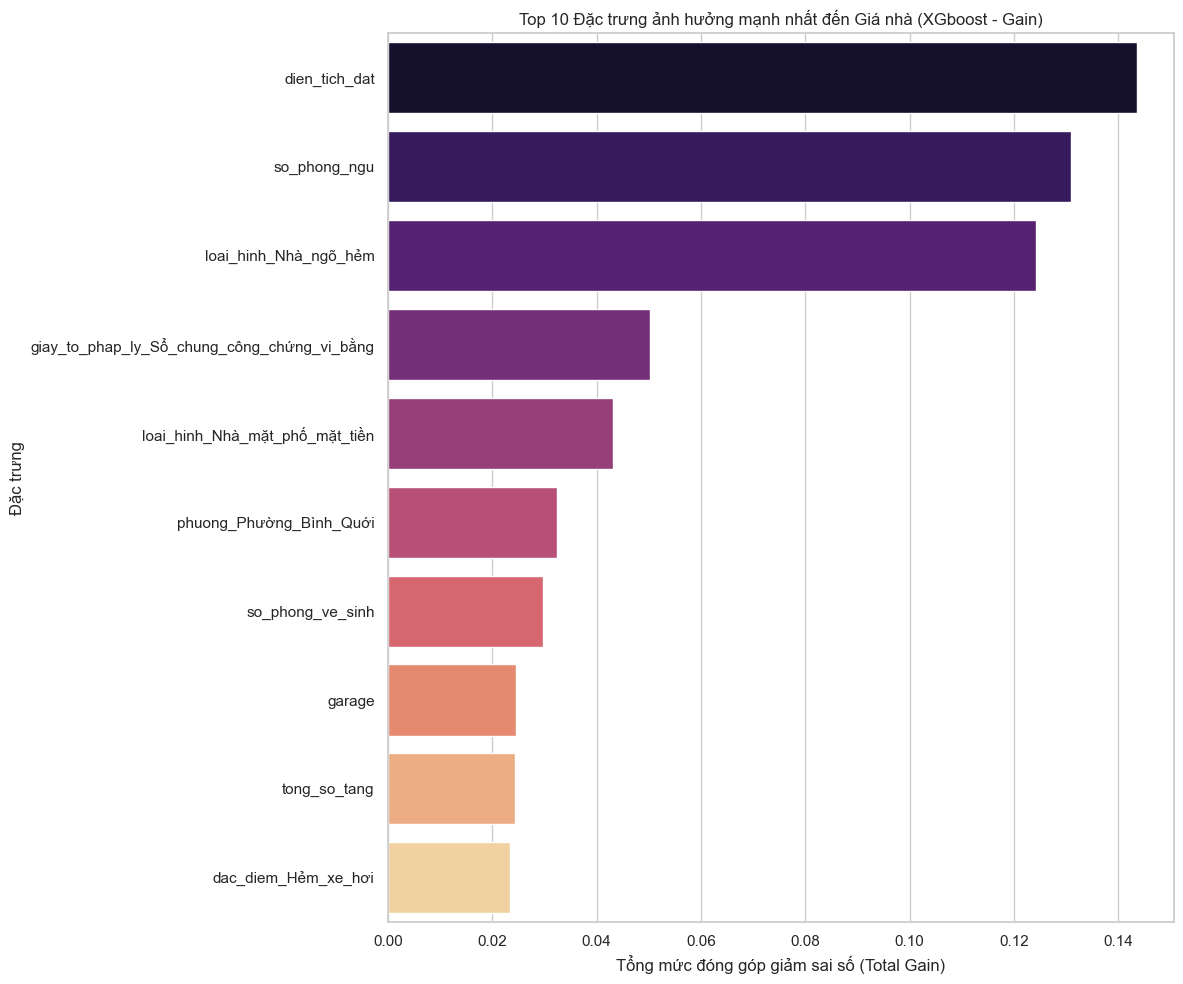

In [117]:
best_model = xgb_grid.best_estimator_
# độ quan trọng theo gain
importance_type = 'gain'
importances = best_model.feature_importances_
feature_names = X_train.columns

# dataframe để sắp xếp
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# top 20 đặc trưng quan trg nhất
plt.figure(figsize=(12, 10))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='magma')
plt.title(f'Top 10 Đặc trưng ảnh hưởng mạnh nhất đến Giá nhà (XGboost - {importance_type.capitalize()})')
plt.xlabel('Tổng mức đóng góp giảm sai số (Total Gain)')
plt.ylabel('Đặc trưng')
plt.tight_layout()
plt.show()

In [118]:
import joblib 
xgb_grid.fit(X, y)
best_model = xgb_grid.best_estimator_
joblib.dump(best_model, "C:/DL07_Do_An/Streamlit_project/models/xgboost.pkl")

Fitting 10 folds for each of 50 candidates, totalling 500 fits


['C:/DL07_Do_An/Streamlit_project/models/xgboost.pkl']

In [119]:
def plot_prediction_vs_actual(y_true, y_pred, figsize=(8, 6)):
    """
    Plot predicted vs actual values for regression.

    Parameters:
    -----------
    y_true : array-like
        True target values
    y_pred : array-like
        Predicted values
    figsize : tuple
        Figure size
    """
    plt.figure(figsize=figsize)

    # Scatter plot
    plt.scatter(y_true, y_pred, alpha=0.6, color='blue', s=50)

    # Perfect prediction line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

    # Calculate R²
    from sklearn.metrics import r2_score
    r2 = r2_score(y_true, y_pred)

    plt.xlabel('Actual Values', fontweight='bold')
    plt.ylabel('Predicted Values', fontweight='bold')
    plt.title(f'🎯 Predicted vs Actual Values (R² = {r2:.3f})', fontweight='bold', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Add text with metrics
    from sklearn.metrics import mean_squared_error, mean_absolute_error
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    textstr = f'R² = {r2:.3f}\nRMSE = {rmse:.2f}\nMAE = {mae:.2f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=12,
             verticalalignment='top', bbox=props)

    plt.tight_layout()
    plt.show()

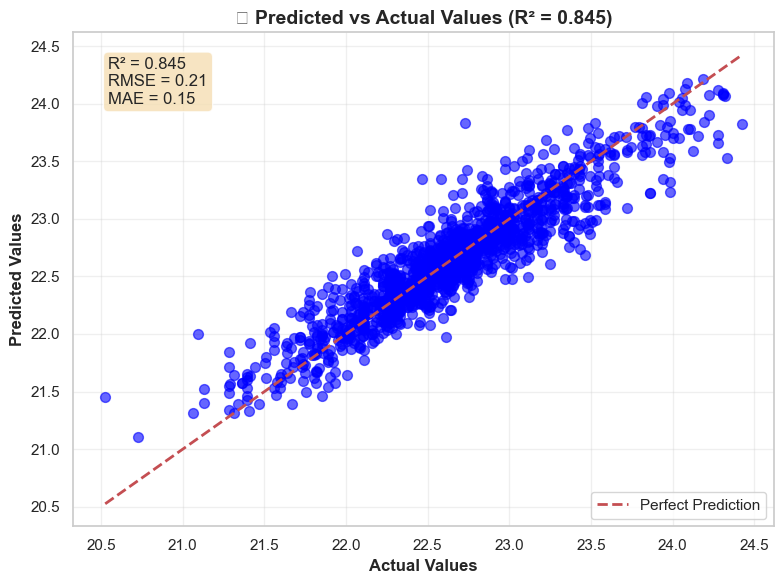

In [120]:
plot_prediction_vs_actual(y_test, yhat)

# **Anomaly Detection**
* Xây dựng function/bộ quy luật **phát hiện bất thường.**
  * **Target:** Danh sách các nhà ở có giá **quá rẻ / quá đắt** so
với dự đoán & thị trường.
* Các dấu hiệu được sử dụng để nhận biết:
  * **Residual-z:** resid = `Giá_thực` − `Giá_dự_đoán`, chuẩn hoá theo phân khúc, khu vực.
  * **Vi phạm min/max:** vượt ngoài Giá_min/Giá_max.
  * **Ngoài khoảng tin cậy:** `Giá_thực` ∉ [P10,P90].
  * **Unsupervised:** Isolation Forest / LOF / One-Class SVM trên vector đặc trưng (kèm resid/z).

In [33]:
import joblib  
best_model = joblib.load('C:/DL07_Do_An/Streamlit_project/models/xgboost.pkl')
y_pred_train = best_model.predict(X) 

In [34]:
import joblib
from anomaly_detector import AnomalyDetector

detector = AnomalyDetector()

detector.fit(
    df_X=X,
    y_true=np.expm1(y),
    y_pred=np.expm1(y_pred_train),
    min_price=500_000_000,
    max_price=50_000_000_000,
)

joblib.dump(detector, "C:/DL07_Do_An/Streamlit_project/models/anomaly_detector.pkl")
print("Saved new anomaly_detector.pkl")

Saved new anomaly_detector.pkl
